## suda plot


### import model

In [1]:
import argparse
from model.TSPN import Transparent_Signal_Processing_Network
from trainer.trainer_basic import Basic_plmodel

import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
parser = argparse.ArgumentParser(description='TSPN')
parser.add_argument('--config_dir', type=str, default='configs/a_temp_SUDA_electric/config_basic.yaml',help='The directory of the configuration file')
# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
signal_processing_modules, feature_extractor_modules = config_network(configs,args)
MODEL_DICT = {'TSPN': lambda args: Transparent_Signal_Processing_Network(signal_processing_modules, feature_extractor_modules,args)}
model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_suda/gen/model_tspn_suda.ckpt")
model.load_state_dict(state_dict['state_dict'])
print(model)

Running experiment: model_TSPNtime20-20-57-04_dataseta_temp_SUDA_basic_it0
# build signal processing layers
# build feature extractor layers
# build classifier


RuntimeError: Error(s) in loading state_dict for Basic_plmodel:
	Missing key(s) in state_dict: "network.clf.clf.3.weight", "network.clf.clf.3.bias". 
	Unexpected key(s) in state_dict: "network.clf.clf.2.weight", "network.clf.clf.2.bias". 
	size mismatch for network.clf.clf.0.weight: copying a param with shape torch.Size([128, 195]) from checkpoint, the shape in current model is torch.Size([64, 195]).
	size mismatch for network.clf.clf.0.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([64]).

### 绘制 SOL矩阵

In [2]:
def plot_weight(weight, name):
    plt.imshow(weight, cmap='Oranges')
    plt.xticks([])
    plt.yticks([])
    plt.colorbar()
    plt.savefig('save/figure/suda/weight/'+ f'{name}.svg')
    plt.clf()
for i in range(4):
    weight_sol = model.network.signal_processing_layers[i].weight_connection.weight
    weight_sol = weight_sol.detach().cpu().numpy()
    plot_weight(weight_sol, 'weight_sol_' + str(i))

<Figure size 640x480 with 0 Axes>

### 加载测试信号

In [3]:
test_data = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_data.npy")
print(test_data.shape)

(204, 1024, 5)


### 绘制融合信号（时域&频域）

In [4]:
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
fault_type_list = ['花键螺母卡滞', '螺旋螺母卡滞', '正常', '缺滚珠']
def get_TSPN_signal(model, signal,i):
    with torch.no_grad():
        for idx, layer in enumerate(model.signal_processing_layers):
            signal = layer(signal)
            if idx == i:
                break
    return signal

def compute_frequency_domain(signal):
    fft_values = torch.fft.rfft(signal)
    fft_values = fft_values.detach().cpu().numpy()
    # 去除直流项
    fft_values[0] = 0
    return np.abs(fft_values)

def plot_signal(signal, savename):
    plt.rcParams['font.family'] = 'Times New Roman'
    # 中文字体及正负号
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['font.family'] = 'SimHei'
    fig, axs = plt.subplots(5, 2, figsize=(16, 4))
   
    for i in range(5):
        signal_time = F.normalize(signal[i,:],dim=0)
        t = np.linspace(0, 1, signal_time.shape[0])
        signal_time = signal_time.detach().cpu().numpy()
        signal_fft = compute_frequency_domain(signal[i,:])
        axs[i,0].plot(t, signal_time,linewidth=1.0 ,c='peru')
        axs[i,1].plot(signal_fft,linewidth=1.0 ,c='darkolivegreen')
        if i == 4:
            # axs[i,0].set_xlabel('Time (s)')
            # axs[i,1].set_xlabel('Frequency (Hz)')
            axs[i,0].set_xlabel('时间 (s)')
            axs[i,1].set_xlabel('频率 (Hz)')
        else:
            axs[i,0].set_xticks([])
            axs[i,1].set_xticks([])
    fig.subplots_adjust(wspace=0.1, hspace=0.1)
    # fig.tight_layout()
    plt.savefig(savename)

def plot_ori_signal(number, signal):
    plt.rcParams['font.family'] = 'Times New Roman'
    # 中文字体及正负号
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['font.family'] = 'SimHei'

    test_signal = signal[number,:,:].unsqueeze(0)
    
    fig, axs = plt.subplots(5, 2, figsize=(16, 4))
    for i in range(5):
        signal_time = F.normalize(test_signal[0,:,i],dim=0)
        t = np.linspace(0, 1, signal_time.shape[0])
        signal_time = signal_time.detach().cpu().numpy()
        signal_fft = compute_frequency_domain(test_signal[0,:,i])
        axs[i,0].plot(t, signal_time,linewidth=0.5 ,c='peru')
        axs[i,1].plot(signal_fft,linewidth=0.5 ,c='darkolivegreen')
        if i == 4:
            # axs[i,0].set_xlabel('Time (s)')
            # axs[i,1].set_xlabel('Frequency (Hz)')
            axs[i,0].set_xlabel('时间 (s)')
            axs[i,1].set_xlabel('频率 (Hz)')
    # fig.tight_layout()
    plt.savefig('save/figure/suda/signal/ori/'+fault_type_list[number//51]+'_original.svg')

torch.Size([15, 1024])
torch.Size([15, 1024])
torch.Size([15, 1024])
torch.Size([15, 1024])


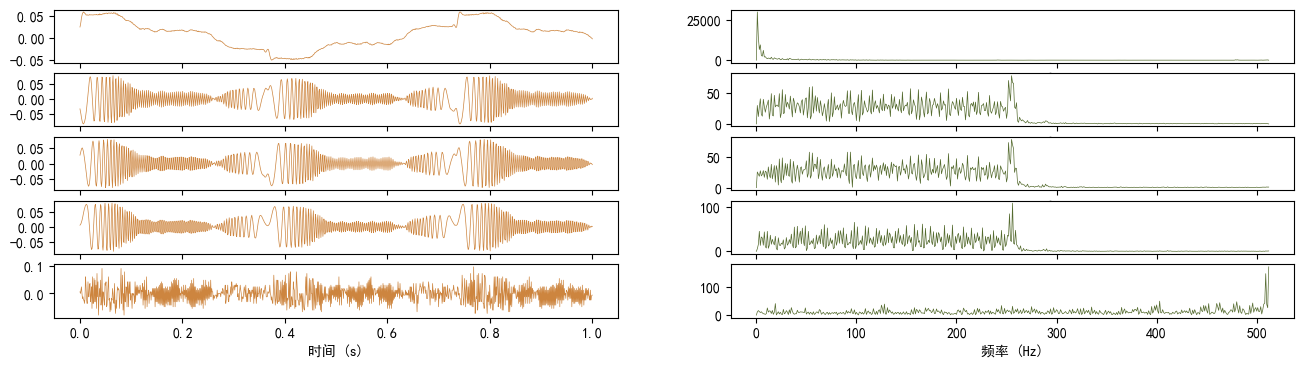

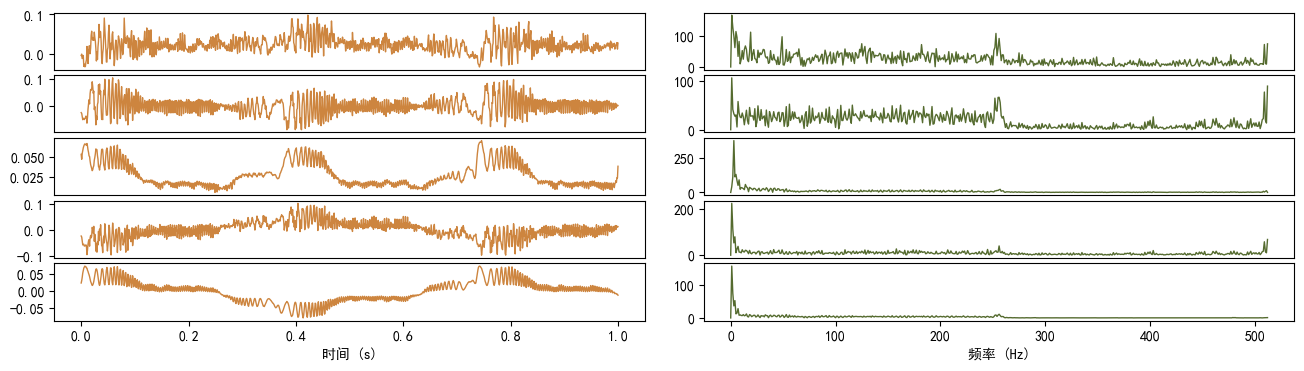

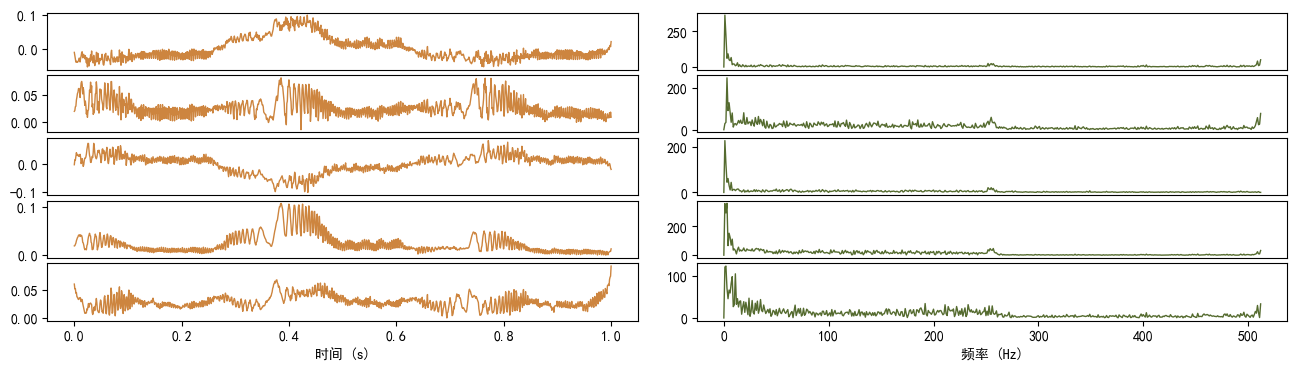

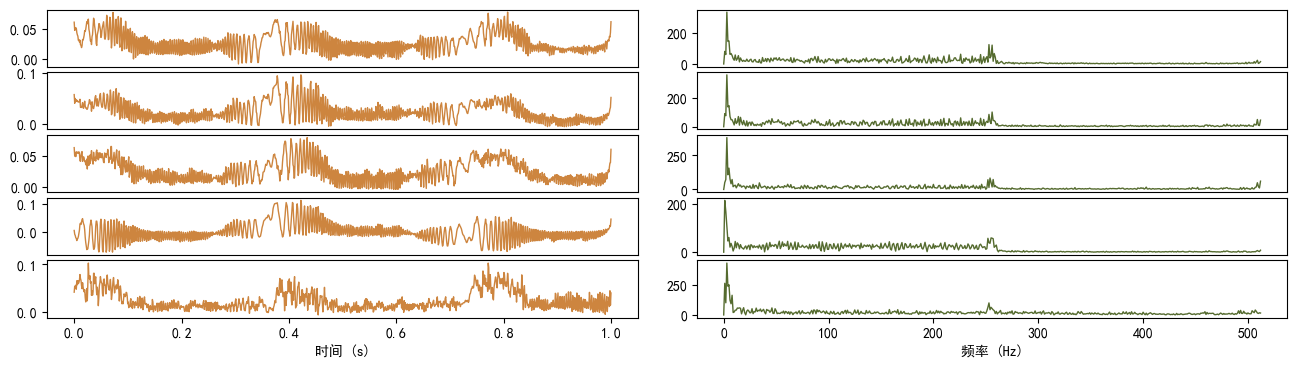

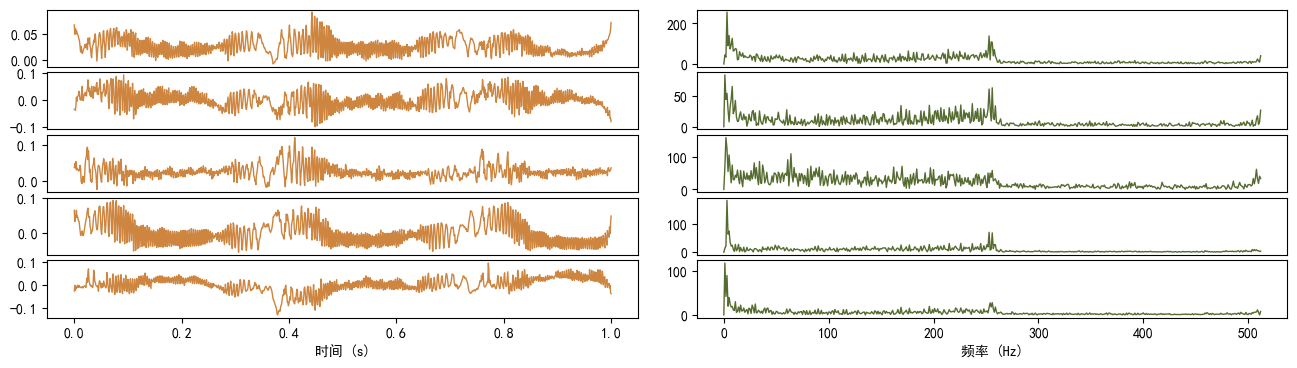

In [5]:
test_signal = torch.from_numpy(test_data).cuda().float()
signal_num_list = [10]
for signal_num in signal_num_list:
    torch.cuda.empty_cache()
    plot_ori_signal(signal_num, test_signal)
    for i in range(4):
        output_signal = get_TSPN_signal(model.network.cuda(), test_signal, i)[signal_num,:,:]
        output_signal = output_signal.T
        plot_signal(output_signal, 'save/figure/suda/signal/tspn/' + str(i) + '.svg')
        print(output_signal.shape)

### 计算特征函数

In [6]:
def get_TSPN_feature(model, signal):
    with torch.no_grad():
        for idx, layer in enumerate(model.signal_processing_layers):
            signal = layer(signal)
        x = model.feature_extractor_layers(signal)
    return x

### umap 绘制函数

In [7]:
import umap.umap_ as umap
def plot_Umap(feature, y_label, fault_type_list, savename='umap_plot'):
    plt.rcParams['font.family'] = 'Times New Roman'
    # n_neighbors 控制局部邻域的大小，较小的值关注局部结构，较大的值关注全局结构
    # min_dist 控制嵌入点之间的最小距离
    # n_components 是降维后的维度，通常为 2 以便可视化
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)

    # 使用特征数据拟合模型并进行降维
    embedding = reducer.fit_transform(feature.detach().cpu().numpy())

    # 可视化
    plt.figure(figsize=(8, 6))

    # 使用不同的颜色绘制不同类别的点
    color_list = ['#98C897', '#9C6BA3', '#9DBAD2', '#FE9C9D',
                  '#291173', '#356529', '#611A44', '#832F87',
                  '#858A2E', '#A75265']
    unique_labels = np.unique(y_label)

    for i, label in enumerate(unique_labels):
        idx = y_label == label
        plt.scatter(embedding[idx, 0], embedding[idx, 1], color=color_list[i], label=fault_type_list[int(label)] if int(label) < len(fault_type_list) else f'类别 {int(label)}', s=50) # s是点的大小

    # plt.title('UMAP projection of the features', fontsize=15)
    # plt.legend(fontsize=18, loc='upper right')
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    # 保存图像
    plt.savefig('save/figure/' + savename + '_umap.svg')

d:\anaconda3\envs\phm_bench\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 绘制suda_umap图

torch.Size([204, 195])
(204,)


d:\anaconda3\envs\phm_bench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


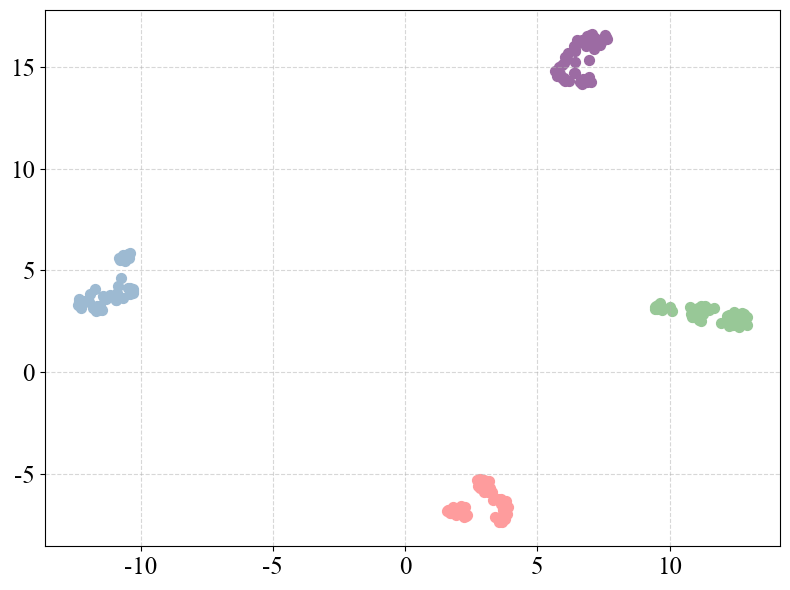

In [ ]:
feature = get_TSPN_feature(model.network.cuda(), test_signal)
print(feature.shape)
y_label = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_label.npy")
print(y_label.shape)
fault_type_list = ['Stuck 1', 'Stuck 2', 'Norm', 'Ball']
plot_Umap(feature, y_label, fault_type_list, 'suda/feature/tspn')

## 对比方法_MWACNN

### import model

In [8]:
import argparse
from model_collection.Resnet import ResNet, BasicBlock
from model_collection.Sincnet import Sincnet,Sinc_net_m
from model_collection.WKN import WKN,WKN_m
from model_collection.EELM import Dong_ELM
from model_collection.MWA_CNN import A_cSE,Huan_net
from model_collection.TFN.Models.TFN import TFN_Morlet
from model_collection.MCN.models import MCN_GFK, MultiChannel_MCN_GFK
from model_collection.MCN.models import MCN_WFK,MultiChannel_MCN_WFK
from trainer.trainer_basic import Basic_plmodel
from einops import rearrange
import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_temp_SUDA_electric/config_MWA_CNN_basic.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
            'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
            'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
            'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes)
        }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_suda/gen/model_mwacnn_suda.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)


Running experiment: model_Huan_nettime20-20-58-02_dataseta_temp_SUDA_basic_it0


<All keys matched successfully>

### 计算特征函数

In [9]:
def get_MWA_CNN_signal(model, signal):
    with torch.no_grad():
        input = rearrange(signal, 'b l c -> b c l')
        DMT_yl,DMT_yh = model.DWT0(input)
        output = torch.cat([DMT_yl,DMT_yh[0]], dim=1)
            
        output = model.SConv1(output)
        DMT_yl,DMT_yh = model.DWT1(output)
        output = torch.cat([DMT_yl,DMT_yh[0]], dim=1)
        output = model.dropout1(output)
        output = model.cSE1(output)
            
        output = model.SConv2(output)
        DMT_yl,DMT_yh = model.DWT2(output)
        output = torch.cat([DMT_yl,DMT_yh[0]], dim=1) 
        output = model.dropout2(output)
        output = model.cSE2(output)
            
        output = model.SConv3(output)
        DMT_yl,DMT_yh = model.DWT3(output)
        output = torch.cat([DMT_yl,DMT_yh[0]], dim=1) 
        output = model.dropout3(output)
        output = model.cSE3(output)
            
        output = model.SConv6(output)
        output = model.avg_pool(output)
        output = output.view(output.size(0), -1)
    return output

### 绘制MWACNN_Umap图

(204, 1024, 5)
torch.Size([204, 96])
(204,)


d:\anaconda3\envs\phm_bench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


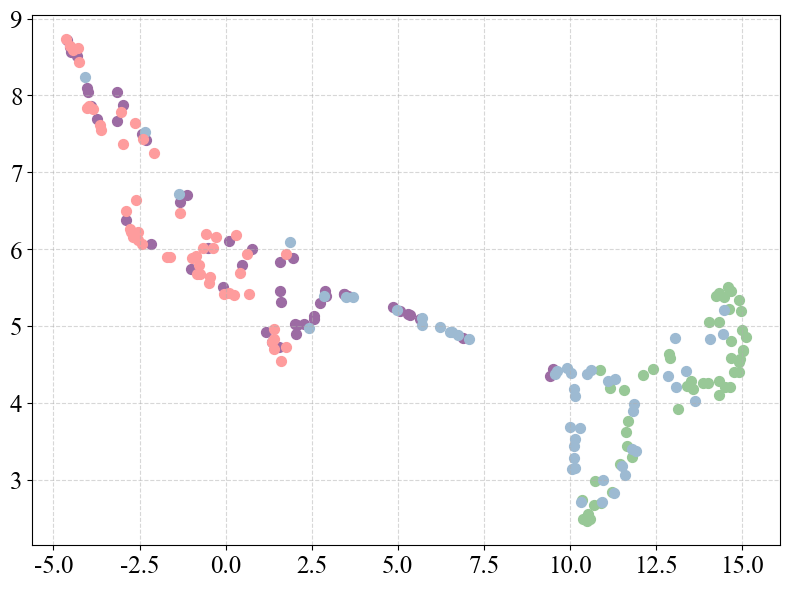

In [10]:
test_signal = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()
feature = get_MWA_CNN_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_label.npy")
print(y_label.shape)
fault_type_list = ['Stuck 1', 'Stuck 2', 'Norm', 'Ball']
plot_Umap(feature, y_label, fault_type_list, 'suda/feature/mwacnn')

## 对比方法_Resnet

### import model

In [11]:
import argparse
from model_collection.Resnet import ResNet, BasicBlock
from model_collection.Sincnet import Sincnet,Sinc_net_m
from model_collection.WKN import WKN,WKN_m
from model_collection.EELM import Dong_ELM
from model_collection.MWA_CNN import A_cSE,Huan_net
from model_collection.TFN.Models.TFN import TFN_Morlet
from model_collection.MCN.models import MCN_GFK, MultiChannel_MCN_GFK
from model_collection.MCN.models import MCN_WFK,MultiChannel_MCN_WFK
from trainer.trainer_basic import Basic_plmodel
from einops import rearrange
import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_temp_SUDA_electric/config_Resnet_basic.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
            'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
            'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
            'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes)
        }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_suda/gen/model_resnet_suda.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)


Running experiment: model_Resnettime20-20-58-35_dataseta_temp_SUDA_basic_it0


<All keys matched successfully>

### 计算特征函数

In [12]:
def get_Resnet_signal(model, signal):
    with torch.no_grad():
        x = rearrange(signal, 'b c n -> b n c')
        x = model.conv1(x)
        x = model.bn1(x)
        x = model.relu(x)
        x = model.maxpool(x)

        x = model.layer1(x)
        x = model.layer2(x)
        x = model.layer3(x)
        x = model.layer4(x)

        x = model.avgpool(x)
        output = x.view(x.size(0), -1)
    return output

### 绘制Resnet Umap图

(204, 1024, 5)
torch.Size([204, 512])
(204,)


d:\anaconda3\envs\phm_bench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


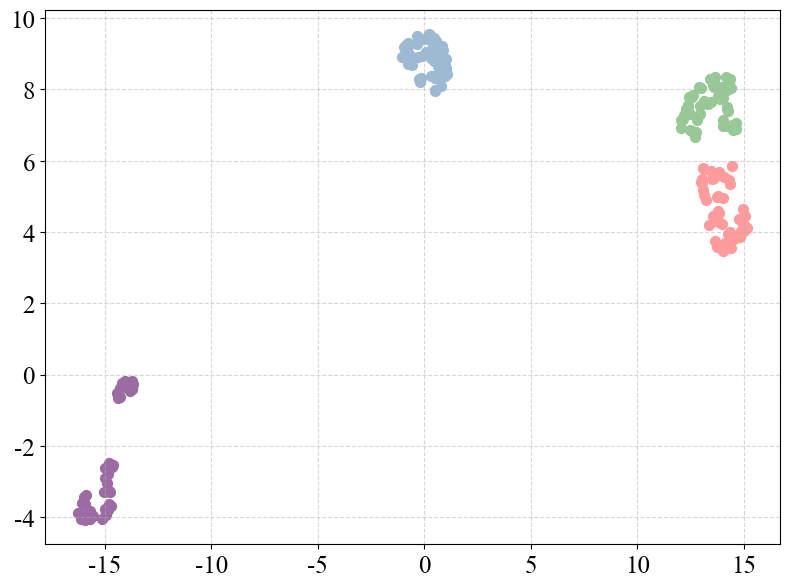

In [13]:
test_signal = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_Resnet_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_label.npy")
print(y_label.shape)
fault_type_list = ['Stuck 1', 'Stuck 2', 'Norm', 'Ball']
plot_Umap(feature, y_label, fault_type_list, 'suda/feature/resnet')

## 对比方法_Sincnet

### import model

In [14]:
import argparse
from model_collection.Resnet import ResNet, BasicBlock
from model_collection.Sincnet import Sincnet,Sinc_net_m
from model_collection.WKN import WKN,WKN_m
from model_collection.EELM import Dong_ELM
from model_collection.MWA_CNN import A_cSE,Huan_net
from model_collection.TFN.Models.TFN import TFN_Morlet
from model_collection.MCN.models import MCN_GFK, MultiChannel_MCN_GFK
from model_collection.MCN.models import MCN_WFK,MultiChannel_MCN_WFK
from trainer.trainer_basic import Basic_plmodel
from einops import rearrange
import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_temp_SUDA_electric/config_Sincnet_basic.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
            'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
            'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
            'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes)
        }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_suda/gen/model_sincnet_suda.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)


Running experiment: model_Sinc_net_mtime20-20-58-46_dataseta_temp_SUDA_basic_it0


<All keys matched successfully>

### 计算特征函数

In [15]:
def get_sincnet_signal(model, signal):
    with torch.no_grad():
        x = rearrange(signal, 'b c n -> b n c')
        x = model.conv1(x)
        x = model.bn1(x)
        x = model.relu(x)
        x = model.maxpool(x)

        x = model.layer1(x)
        x = model.layer2(x)
        x = model.layer3(x)
        x = model.layer4(x)

        x = model.avgpool(x)
        output = x.view(x.size(0), -1)
    return output

### 绘制Sincnet umap图

(204, 1024, 5)
torch.Size([204, 512])
(204,)


d:\anaconda3\envs\phm_bench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


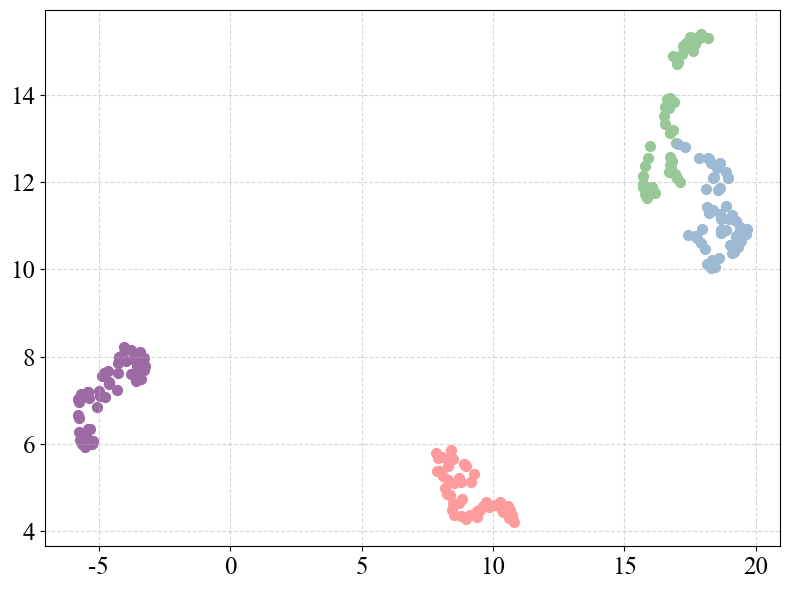

In [16]:
test_signal = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_sincnet_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_label.npy")
print(y_label.shape)
fault_type_list = ['Stuck 1', 'Stuck 2', 'Norm', 'Ball']
plot_Umap(feature, y_label, fault_type_list, 'suda/feature/sincnet')

## 对比方法MCN

### import model

In [17]:
import argparse
from model_collection.Resnet import ResNet, BasicBlock
from model_collection.Sincnet import Sincnet,Sinc_net_m
from model_collection.WKN import WKN,WKN_m
from model_collection.EELM import Dong_ELM
from model_collection.MWA_CNN import A_cSE,Huan_net
from model_collection.TFN.Models.TFN import TFN_Morlet
from model_collection.MCN.models import MCN_GFK, MultiChannel_MCN_GFK
from model_collection.MCN.models import MCN_WFK,MultiChannel_MCN_WFK
from trainer.trainer_basic import Basic_plmodel
from einops import rearrange
import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_temp_SUDA_electric/config_MCN_basic.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
            'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
            'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
            'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes)
        }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_suda/gen/model_mcn_suda.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)


Running experiment: model_MCN_GFKtime20-20-58-58_dataseta_temp_SUDA_basic_it0


<All keys matched successfully>

### 计算特征函数

In [18]:
# filepath: e:\PHM_bench\Unified_X_fault_diagnosis\plot_suda.ipynb
def get_mcn_signal(model, signal):
    with torch.no_grad():
        out = torch.cat([model.features[i](signal[:, :, i].unsqueeze(1)) for i in range(len(model.features))], dim=1)
        out = model.conv(out.real)
        out = model.AdpAvgpool(out)
        out = model.flatten(out)
        out = model.fc(out)
    return out

### 绘制MCN Umap图

(204, 1024, 5)
ModuleList(
  (0-4): 5 x Gaussian_fast()
)
torch.Size([204, 4])
(204,)


d:\anaconda3\envs\phm_bench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


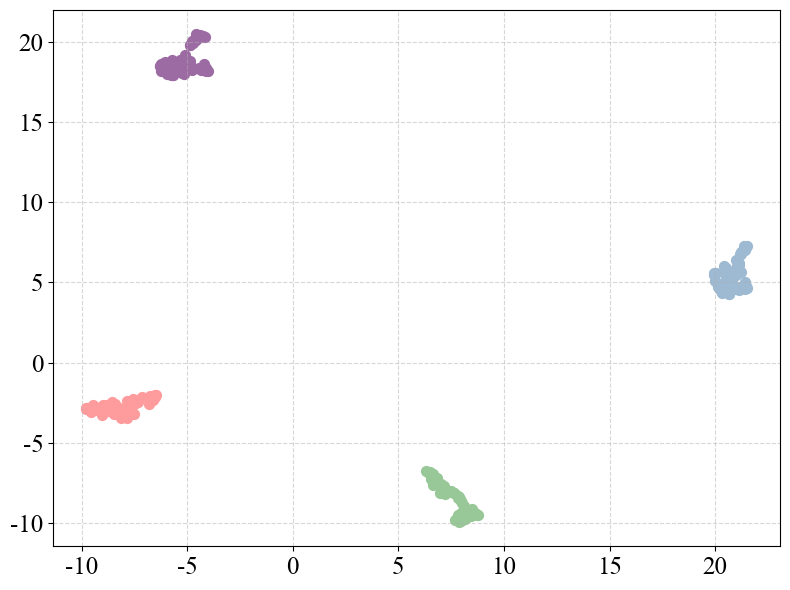

In [19]:
test_signal = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
print(model.network.features)
feature = get_mcn_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_label.npy")
print(y_label.shape)
fault_type_list = ['Stuck 1', 'Stuck 2', 'Norm', 'Ball']
plot_Umap(feature, y_label, fault_type_list, 'suda/feature/mcn')

## 对比方法 BSSTN

### import model

In [24]:
from model_collection.Convformer_NSE import convoformer_v1_small
from model_collection.bsstn_flex import BSSTNFlex
from model_collection.TFN.Models.TFN import TFN_Morlet



parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_temp_SUDA_electric/config_BSSTN_basic.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
                'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
                'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
                'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
                'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
                'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
                'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes),
                'Convoformer_NSE': lambda args: convoformer_v1_small(in_channel=args.in_channels, out_channel=args.num_classes),
                'BSSTN_Flex': lambda args: BSSTNFlex(num_classes=args.num_classes, max_sensors=args.in_channels),
            }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/bsstn.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)


Running experiment: model_BSSTN_Flextime20-21-15-09_dataseta_temp_SUDA_basic_it0


<All keys matched successfully>

### 计算特征函数

In [25]:
from torch_geometric.nn import ChebConv, global_mean_pool as gap, global_max_pool as gmp
def get_bsstn_signal(model, signal):
    with torch.no_grad():
        x = signal
        if x.dim() != 3:
            raise ValueError(f"Expected x with shape [B,L,C], got {tuple(x.shape)}")
        x = x.float()
        B, L, C = x.shape
        if C > model.max_sensors:
            raise ValueError(f"C={C} exceeds max_sensors={model.max_sensors}. Increase max_sensors.")
        # FFT embeddings
        n_fft, hop, T = model._effective_fft_params(L)
        if model.detach_feature:
            with torch.no_grad():
                z = model._extract_fft_feats(x, n_fft=n_fft, hop=hop, T=T)  # [B,T,C,F]
        else:
            z = model._extract_fft_feats(x, n_fft=n_fft, hop=hop, T=T)
        z = model._resize_freq(z, model.Fdim)

        # Build PyG batches
        dataF, dataD = model._build_pyg_batches(z)

        # Add temporal/spatial embeddings (slice spatial embeddings to actual C)
        T = z.shape[1]
        SembF = model.SembF[:C].to(z.device)
        SembD = model.SembD[:C].to(z.device)

        # data?.x is graph-major: [B*T*C, F]
        xF = dataF.x.view(B, T, C, model.Fdim).permute(0, 2, 1, 3)  # [B,C,T,F]
        TembF = model.TembF[:T].to(z.device)
        xF = xF + TembF.unsqueeze(0).unsqueeze(1) + SembF.unsqueeze(0).unsqueeze(2)
        xF = xF.permute(0, 2, 1, 3).reshape(B * T * C, model.Fdim)

        xD = dataD.x.view(B, T, C, model.Fdim).permute(0, 2, 1, 3)  # [B,C,T,F]
        TembD = model.TembD[:T].to(z.device)
        xD = xD + TembD.unsqueeze(0).unsqueeze(1) + SembD.unsqueeze(0).unsqueeze(2)
        xD = xD.permute(0, 2, 1, 3).reshape(B * T * C, model.Fdim)

        # Replace batch x with embedded x
        dataF.x = xF
        dataD.x = xD

        # Mid-step node indices (for pooling)
        idx = model._mid_step_idx(B, C, T, z.device)
        bF = dataF.batch[idx]
        bD = dataD.batch[idx]

        # Function view
        hF = F.relu(model.bnF1(model.convF1(dataF.x, dataF.edge_index)))
        hF = F.relu(model.bnF2(model.convF2(hF, dataF.edge_index)))
        featF = torch.cat([gmp(hF[idx], bF), gap(hF[idx], bF)], dim=1)  # [B, 2*h2]
        logitF = model.linF(featF)

        # Physical view
        hD = F.relu(model.bnD1(model.convD1(dataD.x, dataD.edge_index)))
        hD = F.relu(model.bnD2(model.convD2(hD, dataD.edge_index)))
        featD = torch.cat([gmp(hD[idx], bD), gap(hD[idx], bD)], dim=1)
        logitD = model.linD(featD)

        fusion = torch.cat([featF, featD], dim=1)  # [B, 4*h2]
    return fusion

### 绘制bsstn umap

(204, 1024, 5)
torch.Size([204, 256])
(204,)


d:\anaconda3\envs\phm_bench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


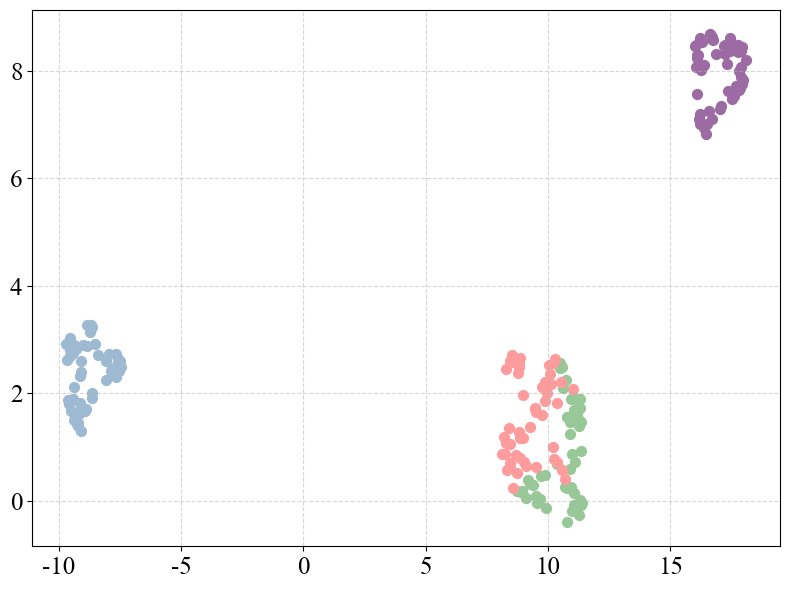

In [26]:
test_signal = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_bsstn_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_label.npy")
print(y_label.shape)
fault_type_list = ['Stuck 1', 'Stuck 2', 'Norm', 'Ball']
plot_Umap(feature, y_label, fault_type_list, 'suda/feature/bsstn')

## 对比convformer

In [38]:
parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_temp_SUDA_electric/config_Convoformer_NSE_basic.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
                'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
                'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
                'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
                'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
                'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
                'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes),
                'Convoformer_NSE': lambda args: convoformer_v1_small(in_channel=args.in_channels, out_channel=args.num_classes),
                'BSSTN_Flex': lambda args: BSSTNFlex(num_classes=args.num_classes, max_sensors=args.in_channels),
            }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/convf.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)

Running experiment: model_Convoformer_NSEtime20-21-55-43_dataseta_temp_SUDA_basic_it0


<All keys matched successfully>

### 计算特征函数

In [39]:
def getconf_signal(model, signal):
    with torch.no_grad():
        x = rearrange(signal, 'b l c -> b c l')
        b = x.shape[0]
        x = model.stem(x)
        x = model.stage1(x)
        f0 = x
        x = model.patch_merging1(x)
        x = model.stage2(x)
        f1 = x
        x = model.patch_merging2(x)
        x = model.stage3(x)
        f2 = x
        if model.use_last:
            x = model.nse(x)
        else:
            f0 = F.interpolate(f0, size=f2.size()[-1])
            f1 = F.interpolate(f1, size=f2.size()[-1])
            x = torch.cat([f0, f1, f2], dim=1)
            x = model.nse(x)
        # [b, c1, n] ==> [b, c1, 1]
        x = model.avg_pool(x)
        x = x.view(b, -1)
    return x

### 绘制umap

(204, 1024, 5)
torch.Size([204, 64])
(204,)


d:\anaconda3\envs\phm_bench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


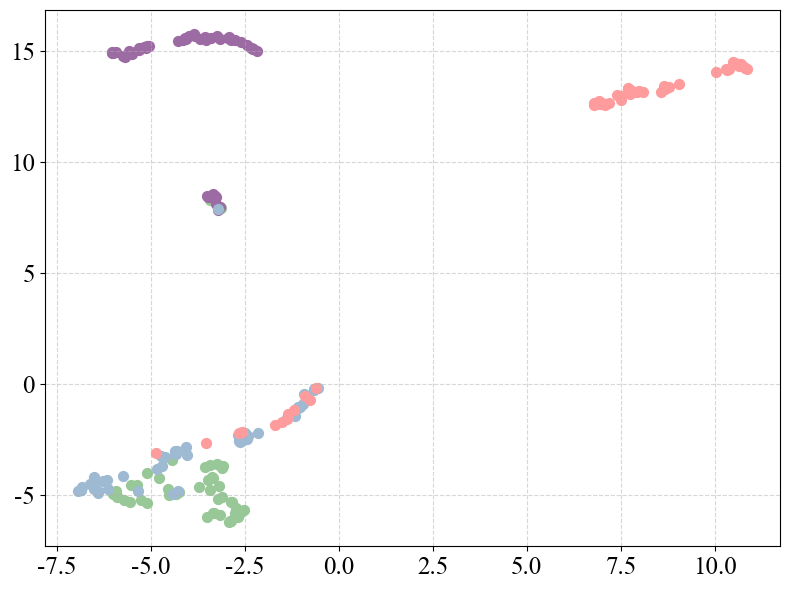

In [40]:
test_signal = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = getconf_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_label.npy")
print(y_label.shape)
fault_type_list = ['Stuck 1', 'Stuck 2', 'Norm', 'Ball']
plot_Umap(feature, y_label, fault_type_list, 'suda/feature/convf')

## TFN

In [41]:
parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_temp_SUDA_electric/config_TFN_basic.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
                'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
                'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
                'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
                'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
                'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
                'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes),
                'Convoformer_NSE': lambda args: convoformer_v1_small(in_channel=args.in_channels, out_channel=args.num_classes),
                'BSSTN_Flex': lambda args: BSSTNFlex(num_classes=args.num_classes, max_sensors=args.in_channels),
            }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/tfn.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)

Running experiment: model_TFN_Morlettime20-21-55-50_dataseta_temp_SUDA_basic_it0


<All keys matched successfully>

### 计算特征函数

In [42]:
def get_tfn_signal(model, signal):
    with torch.no_grad():
        x = model.funconv(signal)
        if len(x.shape) == 4:
            x = torch.squeeze(x)
        x = model.layer1(x)
        x = model.layer2(x)
        x = model.layer3(x)
        x = model.layer4(x)
        x = x.view(x.size(0), -1)
        x = model.layer5(x)
    return x

(204, 1024, 5)
torch.Size([204, 64])
(204,)


d:\anaconda3\envs\phm_bench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


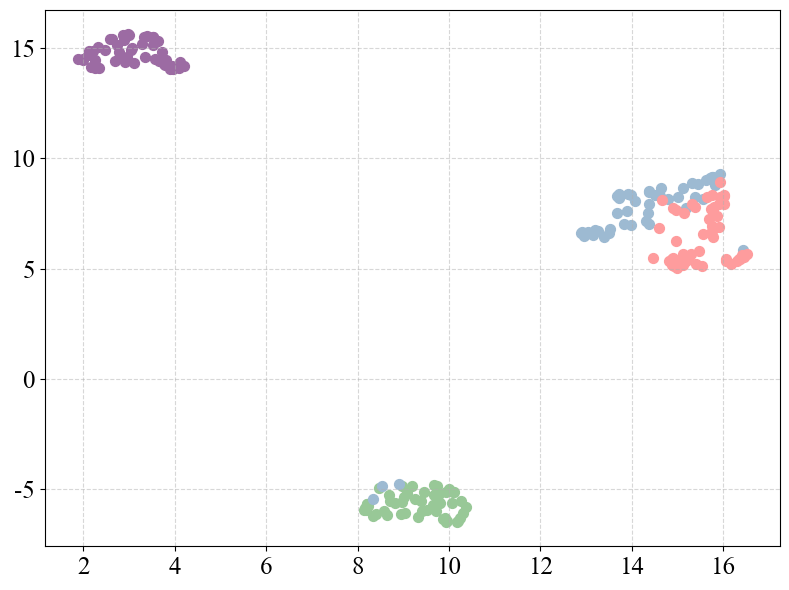

In [45]:
test_signal = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_tfn_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dataset/generate/SUDA_electric/SUDA_electric_0kg_3000r_1000Hz_label.npy")
print(y_label.shape)
fault_type_list = ['Stuck 1', 'Stuck 2', 'Norm', 'Ball']
plot_Umap(feature, y_label, fault_type_list, 'suda/feature/tfn')